# Imports

- **Replace Null Values in Age column**

### 4- Handle Outliers

- **Check for Outliers**

In [11]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [12]:
print(5)

5


In [ ]:
import pandas as pd
df = pd.read_excel("C:/Users/11/OneDrive - Future University in Egypt/Desktop/DEPI/CA-R5-S2S2-AI/src/DA/Session-3&4/assignments/project/data/raw/Titanic.xlsx")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
pip install chardet

   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.2 MB ? eta -:--:--
   --------------------------- ------------ 0.8/1.2 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 1.2/1.2 MB 2.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
df =df.dropna('PassengerId', axis = 1, inplace= True)
df.head()

TypeError: DataFrame.dropna() takes 1 positional argument but 2 positional arguments (and 2 keyword-only arguments) were given

## Chk datatype

In [4]:
dtypes = df.dtypes
n_uniq = df.nunique()
pd.DataFrame({"Dtype":dtypes, "Num_Uniqe":n_uniq}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,object,float64,int64,int64,float64,object,object
Num_Uniqe,2,3,2,88,7,7,248,147,3


In [5]:
def chk_types(data):
    dtypes = df.dtypes
    n_uniq = df.nunique()
    
    return pd.DataFrame({"Dtype":dtypes, "Num_Uniqe":n_uniq}).T

In [6]:
def chk_types_table(data):
    return pd.DataFrame({
        "Dtype": data.dtypes,
        "Num_Unique": data.nunique()
    }).T


In [7]:
chk_types_table(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,object,float64,int64,int64,float64,object,object
Num_Unique,2,3,2,88,7,7,248,147,3


In [73]:
cols = ['Pclass',
        'Survived',
        'Sex',
        'SibSp',
        'Parch',
        'Embarked']
df[cols] = df[cols].astype('category')


In [9]:
chk_types(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,category,category,category,float64,category,category,float64,object,category
Num_Uniqe,2,3,2,88,7,7,248,147,3


In [10]:
df.shape[0]

891

In [11]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Null,0.0,0.0,0.0,177.00000,0.0,0.0,0.0,687.000000,2.000000
ratio %,0.0,0.0,0.0,19.86532,0.0,0.0,0.0,77.104377,0.224467


In [12]:
median_1 = df['Age'].median()
df['Age'].fillna(median_1, inplace=True)


In [89]:
df =df.dropna(subset=['Embarked'], inplace= True)


AttributeError: 'NoneType' object has no attribute 'dropna'

In [14]:
null = df.isnull().sum()
ratio = (null/ df.shape[0])*100
pd.DataFrame({"Null":null, "ratio % ":ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio %,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


findfont: Failed to find font weight medium, now using 400.


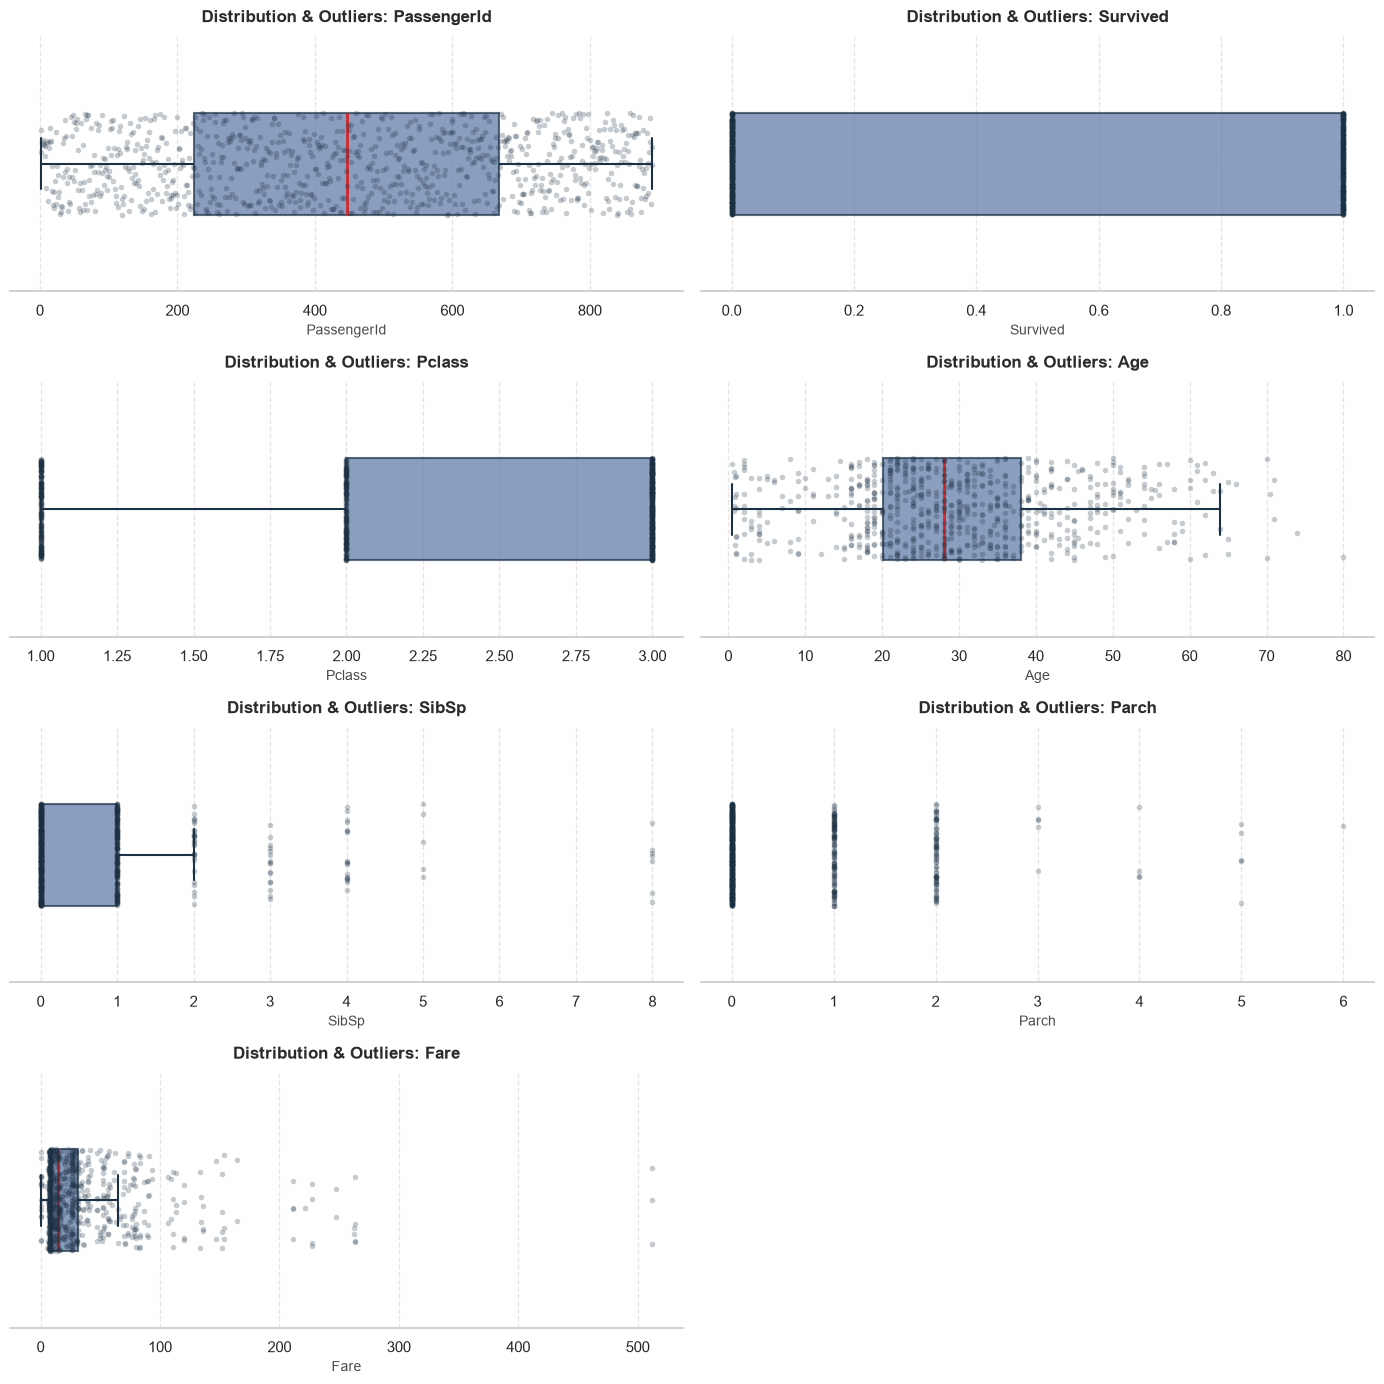

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# ضبط الثيم العام ليصبح عصري ونظيف
sns.set_theme(style="whitegrid", font="sans-serif")

num_cols = df.select_dtypes("number").columns
n_cols = len(num_cols)
n_rows = (n_cols + 1) // 2

# إنشاء الـ Subplots باستخدام plt.subplots لإدارة أسهل وأرتب
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 3.5 * n_rows))
axes = axes.flatten()  # تحويل المصفوفة لـ 1D لسهولة الـ Iteration

for i, col in enumerate(num_cols):
    ax = axes[i]

    # رسم الـ Boxplot مع شريط توزيع النقاط (Stripplot) لإعطاء عمق وتفاصيل أكثر
    sns.boxplot(
        x=df[col],
        ax=ax,
        color="#4C72B0",  # لون أزرق هادئ
        width=0.4,
        fliersize=0,  # إخفاء الـ Outliers القديمة لأن الـ stripplot هيعرضها بشك أرق
        boxprops=dict(alpha=0.7, edgecolor="#1C3144", linewidth=1.5),
        whiskerprops=dict(color="#1C3144", linewidth=1.5),
        capprops=dict(color="#1C3144", linewidth=1.5),
        medianprops=dict(color="#D62728", linewidth=2),  # تمييز الوسيط باللون الأحمر
    )

    # إضافة نقاط البيانات التوضيحية (Stripplot)
    sns.stripplot(
        x=df[col],
        ax=ax,
        color="#1C3144",
        alpha=0.25,
        size=4,
        jitter=0.2,
    )

    # تحسين العناوين والمحاور
    ax.set_title(
        f"Distribution & Outliers: {col}",
        fontsize=12,
        fontweight="bold",
        pad=10,
        color="#2B2B2B",
    )
    ax.set_xlabel(col, fontsize=10, fontweight="medium", color="#4A4A4A")

    # إزالة الإطارات الجانبية والعلوية لتصمّيم أرق (Minimalist)
    sns.despine(ax=ax, left=True)
    ax.grid(True, linestyle="--", alpha=0.5, axis="x")

# إخفاء أي Subplots فارغة في حال كان عدد الأعمدة فردي
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [22]:
num_cols.drop(['Survived', 'Pclass', 'PassengerId'], inplace=True)

TypeError: Index.drop() got an unexpected keyword argument 'inplace'

In [ ]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1

    Lower_Fence = Q1 - 1.5 * IQR
    Upper_Fence = Q3 + 1.5 * IQR
    
    Lower_Outliers = df[df[col]< Lower_Fence][col].values
    Upper_Outliers = df[df[col] > Upper_Fence][col].values
    df[col].replace(Lower_Outliers, Lower_Fence, inplace= True)
    df[col].replace(Upper_Outliers, Upper_Fence, inplace= True)

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_excel("Titanic.xlsx")

print(df.columns)
df['Age'].describe()

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')


count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

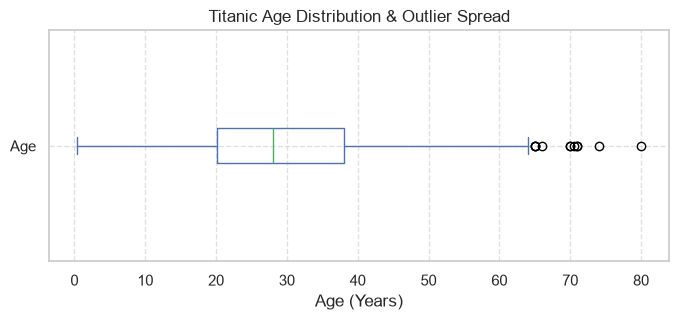

In [29]:
# Visualizing Age distribution via Boxplot
plt.figure(figsize=(8, 3))
df['Age'].plot(kind='box', vert=False, title='Titanic Age Distribution & Outlier Spread')
plt.xlabel('Age (Years)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [30]:
q1 = df['Age'].quantile(0.25)
q3 = df['Age'].quantile(0.75)
iqr = q3 - q1


lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr


df['iqr_outlier'] = ~df['Age'].between(lower_fence, upper_fence) & df['Age'].notna()


print(f"IQR Fences: Lower = {lower_fence:.2f} | Upper = {upper_fence:.2f}")
print(f"IQR Outlier Count: {df['iqr_outlier'].sum()}")


IQR Fences: Lower = -6.69 | Upper = 64.81
IQR Outlier Count: 11


In [31]:
# Calculate sample mean and standard deviation
mean_age = df['Age'].mean()
std_age = df['Age'].std(ddof=1)

# Compute Z-Score and flag points where |Z| > 3
df['z_score'] = (df['Age'] - mean_age) / std_age
df['z_outlier'] = df['z_score'].abs() > 3.0

print(f"Classical Z-Score Outlier Count: {df['z_outlier'].sum()}")

Classical Z-Score Outlier Count: 2


In [32]:
# Compute median and Median Absolute Deviation (MAD)
median_age = df['Age'].median()
mad_age = np.median(np.abs(df['Age'].dropna() - median_age))

# Prevent division by zero and calculate Modified Z-Score
if mad_age == 0:
    df['modified_z'] = np.nan
else:
    df['modified_z'] = 0.6745 * (df['Age'] - median_age) / mad_age

# Flag robust outliers (|Mod_Z| > 3.5)
df['modified_z_outlier'] = df['modified_z'].abs() > 3.5

print(f"MAD: {mad_age:.2f}")
print(f"Modified Z-Score Outlier Count: {df['modified_z_outlier'].sum()}")

MAD: 9.00
Modified Z-Score Outlier Count: 1


In [33]:
flagged_mask = df[['iqr_outlier', 'z_outlier', 'modified_z_outlier']].any(axis=1)
audit_table = df.loc[flagged_mask, ['Age', 'iqr_outlier', 'z_outlier', 'modified_z_outlier']].sort_values('Age', ascending=False)

print("--- Outlier Detection Comparison Table ---")
print(audit_table.head(10))


--- Outlier Detection Comparison Table ---
      Age  iqr_outlier  z_outlier  modified_z_outlier
630  80.0         True       True                True
851  74.0         True       True               False
96   71.0         True      False               False
493  71.0         True      False               False
116  70.5         True      False               False
672  70.0         True      False               False
745  70.0         True      False               False
33   66.0         True      False               False
54   65.0         True      False               False
456  65.0         True      False               False


In [34]:
# Preserve raw values and apply capping
df['Age_raw'] = df['Age']
df['Age_capped'] = df['Age'].clip(lower=lower_fence, upper=upper_fence)


# Compare Raw vs Treated values for flagged passengers
comparison = df.loc[flagged_mask, ['Age_raw', 'Age_capped', 'iqr_outlier', 'z_outlier']]
print("--- Final Treatment Summary ---")
print(comparison.head(5))


--- Final Treatment Summary ---
     Age_raw  Age_capped  iqr_outlier  z_outlier
33      66.0     64.8125         True      False
54      65.0     64.8125         True      False
96      71.0     64.8125         True      False
116     70.5     64.8125         True      False
280     65.0     64.8125         True      False


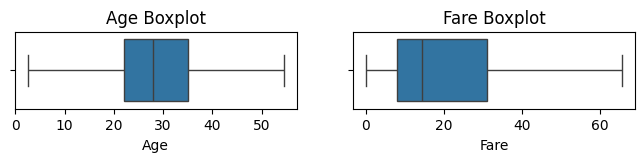

In [17]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2, i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} Boxplot")

In [18]:
df.duplicated().sum()

129

In [19]:
df.drop_duplicates(inplace= True)

In [20]:
df.duplicated().sum()

0

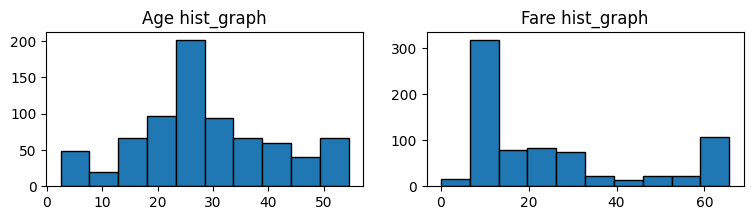

In [21]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(9,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    plt.hist(df[col], edgecolor = "black")
    plt.title(f"{col} hist_graph")
plt.show()


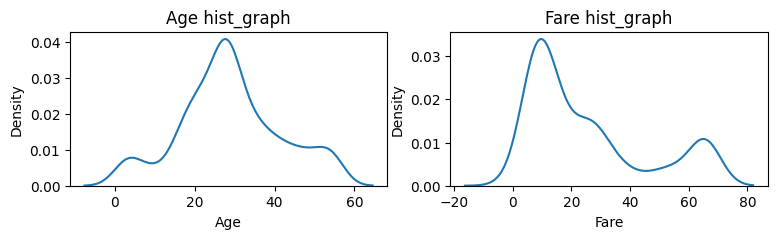

In [22]:
num_cols = df.select_dtypes('number').columns
plt.figure(figsize=(9,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} hist_graph")
plt.show()

In [75]:
cat_cols = df.select_dtypes("category").columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='str')

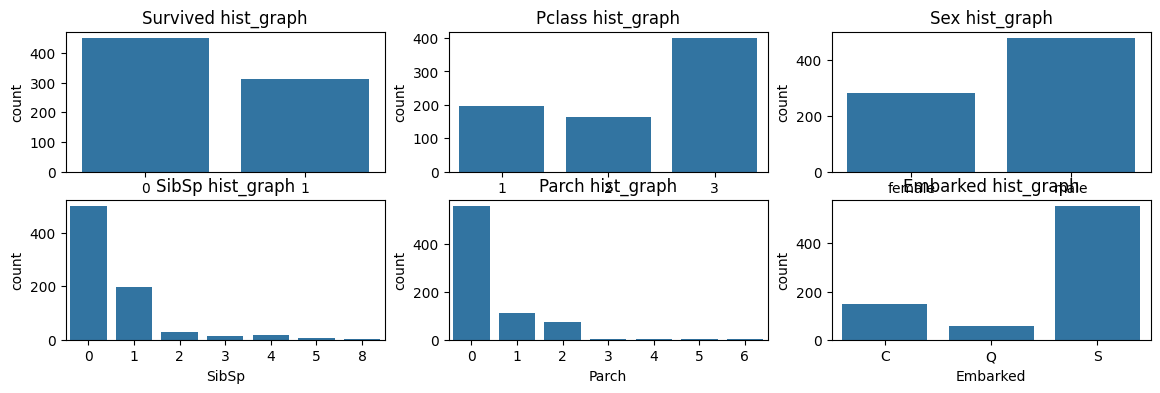

In [24]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    sns.countplot(x = col, data = df)
    plt.title(f"{col} hist_graph")
plt.show()

In [25]:
unique = df['Pclass'].value_counts()
count = unique.values
print(unique)
print(count)

Pclass
3    399
1    198
2    163
Name: count, dtype: int64
[399 198 163]


In [70]:
cat_cols = df.select_dtypes("category").columns

plt.figure(figsize=(9,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3 , i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories =  unique.index
    plt.pie(count, labels=categories, startangle=140, autopct= '%1.1d%%')

<Figure size 900x400 with 0 Axes>

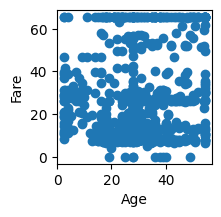

In [27]:
plt.figure(figsize=(2,2))
plt.scatter(df['Age'], df['Fare'])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

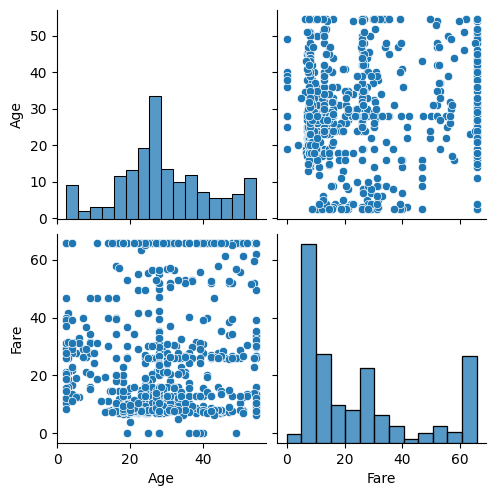

In [28]:
sns.pairplot(df)

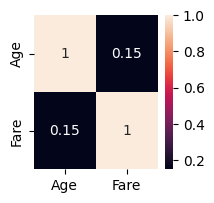

In [29]:
corr  =  df[num_cols].corr()

plt.figure(figsize=(2,2))
sns.heatmap(corr, annot=True)
plt.show()

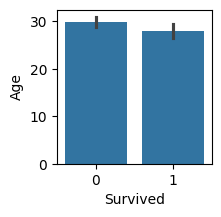

In [30]:
plt.figure(figsize=(2,2))
sns.barplot(x = "Survived", y="Age",data = df)
plt.show()

<Axes: xlabel='Sex', ylabel='Survived'>

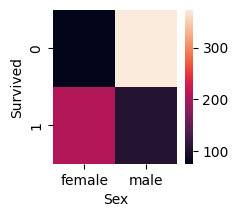

In [31]:
plt.figure(figsize=(2,2))
agg = df.pivot_table(index="Survived", columns="Sex",values="Age", aggfunc=len)
sns.heatmap(agg)


In [25]:
pip install plotly

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.1 MB 1.5 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/9.1 MB 1.8 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.1 MB 1.9 MB/s eta 0:00:05
   -------- ------------------------------- 1.8/9.1 MB 2.1 MB/s eta 0:00:04
   ----------- ---------------------------- 2.6/9.1 MB 2.4 MB/s eta 0:00:03
   --------------- ------------------------ 3.4/9.1 MB 2.5 MB/s eta 0:00:03
   ---------------- ----------------------- 3.7/9.1 MB 2.5 MB/s eta 0:00:03
   ------------------- -------------------- 4.5/9.1 MB 2.6 MB/s eta 0:00:02
   ----------------------- ---------------- 5.2/9.1 MB 2.7 MB/s eta 0:00:02
   -------------------------- ------------- 6.0/9.1 MB 2.8 MB/s eta 0:00:02
   ---------------------------- ----------- 6.6/9.1 MB 2.8 MB/s eta 0:00:01
   -----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import plotly.express as px


In [44]:
!pip install nbformat

  Using cached jupyter_core-5.9.1-py3-none-any.whl.metadata (1.5 kB)
Using cached jupyter_core-5.9.1-py3-none-any.whl (29 kB)

   ---------------------------------------- 0/5 [traitlets]
   ---------------------------------------- 0/5 [traitlets]
   ---------------------------------------- 0/5 [traitlets]
   -------- ------------------------------- 1/5 [platformdirs]
   ---------------- ----------------------- 2/5 [fastjsonschema]
   ---------------- ----------------------- 2/5 [fastjsonschema]
   ------------------------ --------------- 3/5 [jupyter-core]
   ------------------------ --------------- 3/5 [jupyter-core]
   -------------------------------- ------- 4/5 [nbformat]
   -------------------------------- ------- 4/5 [nbformat]
   -------------------------------- ------- 4/5 [nbformat]
   -------------------------------- ------- 4/5 [nbformat]
   -------------------------------- ------- 4/5 [nbformat]
   ---------------------------------------- 5/5 [nbformat]




[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


In [ ]:
fig = px.pie(df, names="Survived",
             title='<b>Survived pie plot</b>',
             color_discrete_map={0: "red", 1: "blue"},
             hole=0.4
             )

fig.add_annotation(text="Survived", font_size=20, x=0.5, y=0.5, showarrow=False)

fig.show()

In [ ]:
import plotly.io as pio
pio.renderers.default = 'browser'
fig.show()

In [54]:
import plotly.express as px
fig = px.pie(df, names="Survived", title='<b>Survived pie plot</b>')
fig.show()

In [67]:
px.histogram(df, x="Survived", color="Sex", barmode="group", title='<b>Survived histogram</b>')

In [80]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
 
fig = make_subplots(rows = 2, cols =3 , subplot_titles=cat_cols)
for i , col in enumerate(cat_cols):
    fig.add_trace(go.Histogram(x =df[col]), row = i //3 + 1 , col = i% 3+1)
fig.show()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [103]:
pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 2.1 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/8.2 MB 2.1 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/8.2 MB 2.1 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/8.2 MB 799.2 kB/s eta 0:00:10
   ------ --------------------------------- 1.3/8.2 MB 1.1 MB/s eta 0:00:07
   -------- ------------------------------- 1.8/8.2 MB 1.4 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.2 MB 1.4 MB/s eta 0:00:05
   -------------- ------------------------- 2.9/8.2 M


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [129]:
X = df.drop(['Survived','Name', 'Ticket', 'Cabin','PassengerId'], axis=1)
y = df['Survived']

In [130]:
X.head(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C


In [131]:
from sklearn.preprocessing import MinMaxScaler
num_col = X.select_dtypes('number').columns
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X[num_col])

In [132]:
X_scaled

array([[1.        , 0.27117366, 0.125     , 0.        , 0.01415106],
       [0.        , 0.4722292 , 0.125     , 0.        , 0.13913574],
       [1.        , 0.32143755, 0.        , 0.        , 0.01546857],
       ...,
       [1.        ,        nan, 0.125     , 0.33333333, 0.04577135],
       [0.        , 0.32143755, 0.        , 0.        , 0.0585561 ],
       [1.        , 0.39683338, 0.        , 0.        , 0.01512699]],
      shape=(891, 5))

In [133]:
pip install one-hot-encoder

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for one-hot-encoder: filename=one_hot_encoder-1.1-py3-none-any.whl size=3546 sha256=199d0c0d58638f1ffa62a8a5259ce66b41987bf608ff3b8a963bc2f5d0f2cd2f
  Stored in directory: c:\users\11\appdata\local\pip\cache\wheels\e0\aa\ef\265640a92cb7a5b922272d6e5b728eb205e2a0a3d62d122701
Successfully built one-hot-encoder
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [138]:
!pip uninstall one-hot-encoder -y

In [140]:
!pip install category_encoders

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 191.8 kB/s eta 0:00:57
   - ------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


In [139]:
from category_encoders import OneHotEncoder
encoder = OneHotEncoder(columns=['Sex', 'Embarked'], drop_invariant=True, use_cat_names=True)
X = encoder.fit_transform(X)

ModuleNotFoundError: No module named 'category_encoders'